In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 1. Load the Iris Dataset

The Iris dataset is a classic and easy-to-understand dataset for classification. It contains measurements of sepal length, sepal width, petal length, and petal width for three species of iris flowers.

In [ ]:
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target # Target labels

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")

Features shape: (150, 4)
Target shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


### 2. Split the Data into Training and Testing Sets

We'll split the dataset into 70% for training and 30% for testing to evaluate the model's performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)


### 3. Initialize and Train the SVM Classifier

We'll use a Support Vector Classifier (`SVC`) with a radial basis function (RBF) kernel, which is a common and effective choice.

In [ ]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


### 4. Make Predictions and Evaluate the Model

Finally, we'll use the trained model to make predictions on the test set and evaluate its performance using accuracy, a classification report, and a confusion matrix.

In [ ]:
y_pred = svm_model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
display(conf_matrix)


--- Model Evaluation ---
Accuracy: 0.9556

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45


Confusion Matrix:


array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  1, 14]])

The confusion matrix shows how many instances of each class were correctly (diagonal) and incorrectly classified.

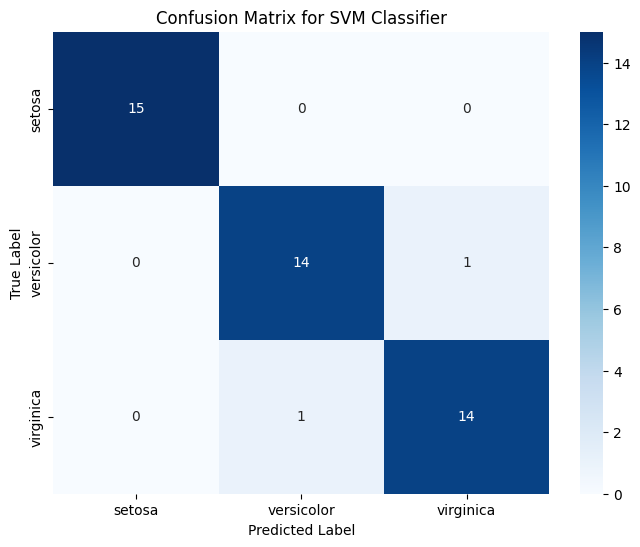

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()